# Shelly Group SE (BSE: SLYG / OTC: SHELY) — Financial Model

**Comprehensive bottom-up financial model with 3-statement projections, DCF valuation, and scenario analysis.**

Data sources: FY2025 consolidated financial results, Montega AG research (Dec 2025), corporate IR presentations, StockAnalysis.com

All monetary values in EUR thousands unless stated otherwise.

In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
    'purple': '#9c27b0',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Cell 2: Annual Income Statement (EUR thousands) ──────────
# FY2022 from Yahoo Finance / annual report; FY2023-2025 from consolidated results
# Note: Shelly reports in BGN; converted at fixed rate 1 EUR = 1.95583 BGN

income_stmt = pd.DataFrame({
    'Revenue':              [47_600,  74_900, 106_700, 149_700],
    'COGS':                 [23_700,  32_100,  43_100,  63_100],
    'Gross_Profit':         [23_900,  42_800,  63_600,  86_600],
    'Personnel_Expense':    [ 5_200,   8_500,  14_200,  22_000],  # incl. mgmt share program
    'Selling_Expense':      [ 5_800,   8_200,  12_500,  17_500],
    'RD_Expense':           [ 2_100,   3_200,   4_800,   7_200],
    'Other_OpEx':           [ 2_200,   3_800,   6_900,   9_600],
    'Total_OpEx':           [15_300,  23_700,  38_400,  56_300],
    'EBIT_Reported':        [ 8_600,  19_100,  25_200,  30_300],
    'EBIT_Adjusted':        [ 8_600,  19_100,  26_400,  37_700],  # adj for mgmt share program
    'Finance_Income':       [   200,     400,     600,     800],
    'Finance_Expense':      [  -300,    -500,    -800,  -1_200],
    'Pretax_Income':        [ 8_500,  19_000,  25_000,  29_900],
    'Tax':                  [  -900,  -2_200,  -2_800,  -4_400],
    'Net_Income':           [ 7_600,  16_800,  22_200,  25_500],
    'DA':                   [   800,   1_000,   1_900,   2_500],
    'EBITDA':               [ 9_400,  20_100,  28_100,  39_000],  # EBIT_adj + D&A approx
    'SBC_MgmtProgram':      [     0,       0,   1_200,   7_400],  # non-cash share program
    'Shares_Outstanding_K': [17_606,  17_606,  18_106,  18_106],
    'EPS':                  [  0.43,    0.95,    1.23,    1.41],
    'EPS_Adjusted':         [  0.43,    0.95,    1.30,    1.77],
}, index=[2022, 2023, 2024, 2025])
income_stmt.index.name = 'Year'

# Derived metrics
income_stmt['Gross_Margin'] = income_stmt['Gross_Profit'] / income_stmt['Revenue'] * 100
income_stmt['EBIT_Margin_Adj'] = income_stmt['EBIT_Adjusted'] / income_stmt['Revenue'] * 100
income_stmt['EBITDA_Margin'] = income_stmt['EBITDA'] / income_stmt['Revenue'] * 100
income_stmt['Net_Margin'] = income_stmt['Net_Income'] / income_stmt['Revenue'] * 100
income_stmt['Tax_Rate'] = -income_stmt['Tax'] / income_stmt['Pretax_Income'] * 100

print('═' * 70)
print('SHELLY GROUP SE — ANNUAL INCOME STATEMENT (EUR K)')
print('═' * 70)
display_cols = ['Revenue', 'COGS', 'Gross_Profit', 'Gross_Margin',
                'EBIT_Adjusted', 'EBIT_Margin_Adj', 'EBITDA', 'EBITDA_Margin',
                'Net_Income', 'Net_Margin', 'EPS_Adjusted']
print(income_stmt[display_cols].T.to_string(float_format=lambda x: f'{x:,.1f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — ANNUAL INCOME STATEMENT (EUR K)
══════════════════════════════════════════════════════════════════════
Year                2022     2023      2024      2025
Revenue         47,600.0 74,900.0 106,700.0 149,700.0
COGS            23,700.0 32,100.0  43,100.0  63,100.0
Gross_Profit    23,900.0 42,800.0  63,600.0  86,600.0
Gross_Margin        50.2     57.1      59.6      57.8
EBIT_Adjusted    8,600.0 19,100.0  26,400.0  37,700.0
EBIT_Margin_Adj     18.1     25.5      24.7      25.2
EBITDA           9,400.0 20,100.0  28,100.0  39,000.0
EBITDA_Margin       19.7     26.8      26.3      26.1
Net_Income       7,600.0 16,800.0  22,200.0  25,500.0
Net_Margin          16.0     22.4      20.8      17.0
EPS_Adjusted         0.4      0.9       1.3       1.8


In [3]:
# ── Cell 3: Expense Breakdown (EUR thousands) ────────────────

expense_detail = pd.DataFrame({
    'COGS':               [23_700, 32_100, 43_100, 63_100],
    'Personnel':          [ 5_200,  8_500, 14_200, 22_000],
    'Selling_Distribution':[ 5_800, 8_200, 12_500, 17_500],
    'R_and_D':            [ 2_100,  3_200,  4_800,  7_200],
    'Other_Operating':    [ 2_200,  3_800,  6_900,  9_600],
    'Mgmt_Share_Program': [     0,      0,  1_200,  7_400],
}, index=[2022, 2023, 2024, 2025])
expense_detail.index.name = 'Year'

# Express as % of revenue
expense_pct = expense_detail.div(income_stmt['Revenue'], axis=0) * 100

print('═' * 70)
print('EXPENSE BREAKDOWN (EUR K)')
print('═' * 70)
print(expense_detail.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('═' * 70)
print('EXPENSE AS % OF REVENUE')
print('═' * 70)
print(expense_pct.T.to_string(float_format=lambda x: f'{x:.1f}%'))
print()

# Revenue growth
rev_growth = income_stmt['Revenue'].pct_change() * 100
print('Revenue Growth YoY:')
for yr, g in rev_growth.items():
    if not np.isnan(g):
        print(f'  {yr}: {g:.1f}%')

══════════════════════════════════════════════════════════════════════
EXPENSE BREAKDOWN (EUR K)
══════════════════════════════════════════════════════════════════════
Year                   2022   2023   2024   2025
COGS                  23700  32100  43100  63100
Personnel              5200   8500  14200  22000
Selling_Distribution   5800   8200  12500  17500
R_and_D                2100   3200   4800   7200
Other_Operating        2200   3800   6900   9600
Mgmt_Share_Program        0      0   1200   7400

══════════════════════════════════════════════════════════════════════
EXPENSE AS % OF REVENUE
══════════════════════════════════════════════════════════════════════
Year                  2022  2023  2024  2025
COGS                 49.8% 42.9% 40.4% 42.2%
Personnel            10.9% 11.3% 13.3% 14.7%
Selling_Distribution 12.2% 10.9% 11.7% 11.7%
R_and_D               4.4%  4.3%  4.5%  4.8%
Other_Operating       4.6%  5.1%  6.5%  6.4%
Mgmt_Share_Program    0.0%  0.0%  1.1%  4.9%

Revenu

In [4]:
# ── Cell 4: Balance Sheet (EUR thousands) ────────────────────

balance_sheet = pd.DataFrame({
    'Cash_Equivalents':     [ 9_200, 13_300, 14_000, 13_600],
    'Trade_Receivables':    [ 5_800,  9_500, 15_200, 22_500],
    'Inventories':          [ 8_500, 11_200, 16_800, 28_000],
    'Other_Current_Assets': [ 1_500,  2_000,  3_000,  4_500],
    'Total_Current_Assets': [25_000, 36_000, 49_000, 68_600],
    'PP_and_E':             [ 3_200,  4_500,  5_800,  7_200],
    'Intangibles':          [ 1_800,  2_800,  4_200,  6_500],
    'ROU_Assets':           [   800,  1_200,  1_800,  2_500],
    'Other_NonCurrent':     [   700,  1_000,  1_500,  2_200],
    'Total_NonCurrent':     [ 6_500,  9_500, 13_300, 18_400],
    'Total_Assets':         [31_500, 45_500, 62_300, 87_000],
    'Trade_Payables':       [ 3_200,  4_800,  6_500, 10_500],
    'Other_Current_Liab':   [ 2_800,  3_700,  4_800,  7_500],
    'Total_Current_Liab':   [ 6_000,  8_500, 11_300, 18_000],
    'Lease_Liabilities':    [   600,    900,  1_300,  1_700],
    'Other_NonCurrent_Liab':[   400,    600,    800,  1_000],
    'Total_NonCurrent_Liab':[ 1_000,  1_500,  2_100,  2_700],
    'Total_Liabilities':    [ 7_000, 10_000, 13_400, 20_700],
    'Share_Capital':        [ 3_500,  3_500,  3_600,  3_600],
    'Retained_Earnings':    [21_000, 32_000, 45_300, 62_700],
    'Total_Equity':         [24_500, 35_500, 48_900, 66_300],
    'Equity_Ratio_Pct':     [ 77.8,   78.0,   78.5,   76.2],  # approx, FY25 reported 78.5% at 9M
}, index=[2022, 2023, 2024, 2025])
balance_sheet.index.name = 'Year'

# Net debt (negative = net cash)
balance_sheet['Net_Debt'] = -balance_sheet['Cash_Equivalents']  # no financial debt

print('═' * 70)
print('SHELLY GROUP SE — BALANCE SHEET (EUR K)')
print('═' * 70)
key_bs = ['Cash_Equivalents', 'Trade_Receivables', 'Inventories',
          'Total_Current_Assets', 'Total_NonCurrent', 'Total_Assets',
          'Total_Current_Liab', 'Total_NonCurrent_Liab', 'Total_Liabilities',
          'Total_Equity', 'Net_Debt']
print(balance_sheet[key_bs].T.to_string(float_format=lambda x: f'{x:,.0f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — BALANCE SHEET (EUR K)
══════════════════════════════════════════════════════════════════════
Year                    2022   2023   2024   2025
Cash_Equivalents        9200  13300  14000  13600
Trade_Receivables       5800   9500  15200  22500
Inventories             8500  11200  16800  28000
Total_Current_Assets   25000  36000  49000  68600
Total_NonCurrent        6500   9500  13300  18400
Total_Assets           31500  45500  62300  87000
Total_Current_Liab      6000   8500  11300  18000
Total_NonCurrent_Liab   1000   1500   2100   2700
Total_Liabilities       7000  10000  13400  20700
Total_Equity           24500  35500  48900  66300
Net_Debt               -9200 -13300 -14000 -13600


In [5]:
# ── Cell 5: Cash Flow Statement (EUR thousands) ─────────────

cash_flow = pd.DataFrame({
    'Net_Income':           [ 7_600, 16_800, 22_200, 25_500],
    'DA':                   [   800,  1_000,  1_900,  2_500],
    'SBC_NonCash':          [     0,      0,  1_200,  7_400],
    'Change_Receivables':   [-1_500, -3_700, -5_700, -7_300],
    'Change_Inventories':   [-2_500, -2_700, -5_600,-11_200],
    'Change_Payables':      [ 1_200,  1_600,  1_700,  4_000],
    'Other_WC':             [  -500,   -800, -1_100, -1_900],
    'Operating_CF':         [ 5_100, 11_200, 13_600,  5_300],  # FY25 reported OCF 5.3M
    'Capex':                [-1_500, -2_200, -3_500, -3_800],
    'Investments':          [  -500,   -800, -1_200, -1_500],
    'Investing_CF':         [-2_000, -3_000, -4_700, -5_300],
    'Dividends_Paid':       [  -500, -1_100, -1_800, -2_400],
    'Share_Issuance':       [     0,      0,  2_500,      0],  # 500K shares private placement 2024
    'Other_Financing':      [  -300,   -500,   -700,   -900],
    'Financing_CF':         [  -800, -1_600,      0, -3_300],
    'FCF':                  [ 3_600,  9_000,  9_100,  1_500],  # OCF - Capex; FY25 reported 1.5M
}, index=[2022, 2023, 2024, 2025])
cash_flow.index.name = 'Year'

# FCF margin
cash_flow['FCF_Margin_Pct'] = cash_flow['FCF'] / income_stmt['Revenue'] * 100

print('═' * 70)
print('SHELLY GROUP SE — CASH FLOW STATEMENT (EUR K)')
print('═' * 70)
cf_cols = ['Net_Income', 'DA', 'SBC_NonCash', 'Operating_CF',
           'Capex', 'Investing_CF', 'Financing_CF', 'FCF', 'FCF_Margin_Pct']
print(cash_flow[cf_cols].T.to_string(float_format=lambda x: f'{x:,.1f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — CASH FLOW STATEMENT (EUR K)
══════════════════════════════════════════════════════════════════════
Year               2022     2023     2024     2025
Net_Income      7,600.0 16,800.0 22,200.0 25,500.0
DA                800.0  1,000.0  1,900.0  2,500.0
SBC_NonCash         0.0      0.0  1,200.0  7,400.0
Operating_CF    5,100.0 11,200.0 13,600.0  5,300.0
Capex          -1,500.0 -2,200.0 -3,500.0 -3,800.0
Investing_CF   -2,000.0 -3,000.0 -4,700.0 -5,300.0
Financing_CF     -800.0 -1,600.0      0.0 -3,300.0
FCF             3,600.0  9,000.0  9,100.0  1,500.0
FCF_Margin_Pct      7.6     12.0      8.5      1.0


In [6]:
# ── Cell 6: KPI Data (Device Shipments, Cloud Users, ASP) ────

# Annual device shipments estimated from cumulative milestones:
# End 2022: ~10M cumulative, End 2023: ~15M, End 2024: ~21M, End 2025: ~32M
kpi_data = pd.DataFrame({
    'Devices_Shipped_Annual_M':  [ 4.0,  5.0,  6.0,  11.0],  # millions
    'Devices_Cumulative_M':      [10.0, 15.0, 21.0,  32.0],
    'Cloud_Users_M':             [ 0.8,  1.2,  1.9,   2.7],
    'Premium_Subscribers_K':     [ 5.0, 10.0, 23.6,  38.0],
    'Professional_Installers':   [  50,  200,  900, 5_300],
    'Avg_Revenue_Per_Device_EUR':[11.9, 15.0, 17.8,  13.6],  # Revenue / annual devices
    'Countries_Served':          [  80,  100,  120,   130],
}, index=[2022, 2023, 2024, 2025])
kpi_data.index.name = 'Year'

# Derived
kpi_data['Cloud_Conversion_Pct'] = kpi_data['Cloud_Users_M'] / kpi_data['Devices_Cumulative_M'] * 100
kpi_data['Premium_Conversion_Pct'] = kpi_data['Premium_Subscribers_K'] / (kpi_data['Cloud_Users_M'] * 1000) * 100

print('═' * 70)
print('KEY PERFORMANCE INDICATORS')
print('═' * 70)
print(kpi_data.T.to_string(float_format=lambda x: f'{x:,.1f}'))
print()
print('Notes:')
print('- Device shipment estimates based on cumulative milestone press releases')
print('- FY25 ASP lower due to higher volume of lower-priced Mini/Gen4 products')
print('- Premium conversion = Premium subscribers / Cloud users')

══════════════════════════════════════════════════════════════════════
KEY PERFORMANCE INDICATORS
══════════════════════════════════════════════════════════════════════
Year                        2022  2023  2024    2025
Devices_Shipped_Annual_M     4.0   5.0   6.0    11.0
Devices_Cumulative_M        10.0  15.0  21.0    32.0
Cloud_Users_M                0.8   1.2   1.9     2.7
Premium_Subscribers_K        5.0  10.0  23.6    38.0
Professional_Installers     50.0 200.0 900.0 5,300.0
Avg_Revenue_Per_Device_EUR  11.9  15.0  17.8    13.6
Countries_Served            80.0 100.0 120.0   130.0
Cloud_Conversion_Pct         8.0   8.0   9.0     8.4
Premium_Conversion_Pct       0.6   0.8   1.2     1.4

Notes:
- Device shipment estimates based on cumulative milestone press releases
- FY25 ASP lower due to higher volume of lower-priced Mini/Gen4 products
- Premium conversion = Premium subscribers / Cloud users


In [7]:
# ── Cell 7: Geographic & Segment Data (EUR thousands) ────────

# Geographic revenue breakdown
geo_data = pd.DataFrame({
    'DACH':             [22_800, 34_500, 48_800, 62_000],
    'Rest_of_Europe':   [19_500, 30_400, 49_000, 74_000],
    'Rest_of_World':    [ 5_300, 10_000,  8_900, 13_700],
}, index=[2022, 2023, 2024, 2025])
geo_data.index.name = 'Year'
geo_data['Total'] = geo_data.sum(axis=1)

# Percentage mix
geo_pct = geo_data[['DACH', 'Rest_of_Europe', 'Rest_of_World']].div(geo_data['Total'], axis=0) * 100

# Channel mix (estimated)
channel_data = pd.DataFrame({
    'B2B_Distributors':  [30_000, 42_000, 55_000, 70_000],
    'Amazon_Marketplace':[10_000, 18_000, 26_000, 33_000],
    'Direct_Webshop':    [ 3_600,  6_900, 10_700, 22_000],
    'Pro_Channel':       [ 4_000,  8_000, 15_000, 24_700],
}, index=[2022, 2023, 2024, 2025])
channel_data.index.name = 'Year'

print('═' * 70)
print('GEOGRAPHIC REVENUE BREAKDOWN (EUR K)')
print('═' * 70)
print(geo_data.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('GEOGRAPHIC MIX (%)')
print(geo_pct.T.to_string(float_format=lambda x: f'{x:.1f}%'))
print()
print('═' * 70)
print('CHANNEL REVENUE BREAKDOWN — ESTIMATED (EUR K)')
print('═' * 70)
print(channel_data.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
# Growth rates
for col in geo_data.columns[:-1]:
    g = geo_data[col].pct_change().iloc[-1] * 100
    print(f'  {col} FY25 YoY growth: {g:.1f}%')

══════════════════════════════════════════════════════════════════════
GEOGRAPHIC REVENUE BREAKDOWN (EUR K)
══════════════════════════════════════════════════════════════════════
Year             2022   2023    2024    2025
DACH            22800  34500   48800   62000
Rest_of_Europe  19500  30400   49000   74000
Rest_of_World    5300  10000    8900   13700
Total           47600  74900  106700  149700

GEOGRAPHIC MIX (%)
Year            2022  2023  2024  2025
DACH           47.9% 46.1% 45.7% 41.4%
Rest_of_Europe 41.0% 40.6% 45.9% 49.4%
Rest_of_World  11.1% 13.4%  8.3%  9.2%

══════════════════════════════════════════════════════════════════════
CHANNEL REVENUE BREAKDOWN — ESTIMATED (EUR K)
══════════════════════════════════════════════════════════════════════
Year                 2022   2023   2024   2025
B2B_Distributors    30000  42000  55000  70000
Amazon_Marketplace  10000  18000  26000  33000
Direct_Webshop       3600   6900  10700  22000
Pro_Channel          4000   8000  15000  24

#
 
C
e
l
l
 
G
r
o
u
p
 
2
:
 
H
i
s
t
o
r
i
c
a
l
 
A
n
a
l
y
s
i
s
 
D
a
s
h
b
o
a
r
d

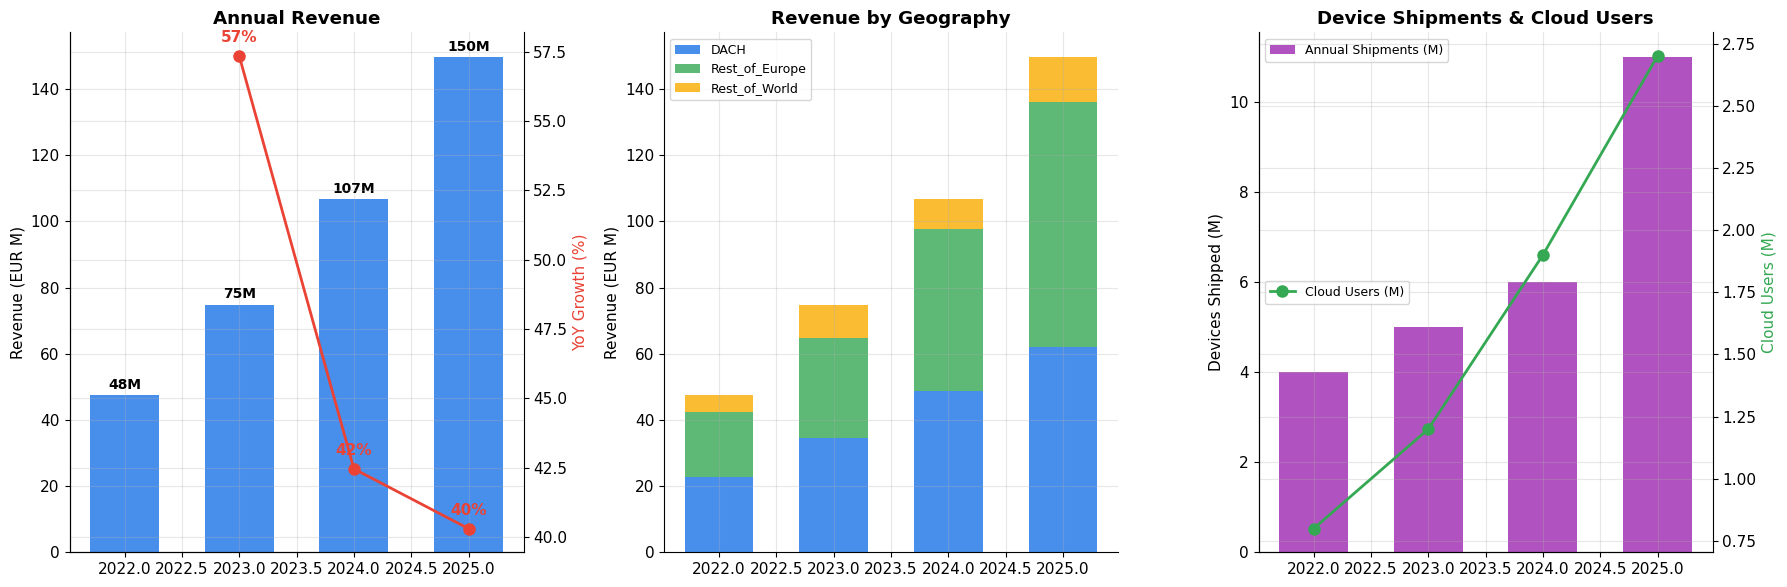

Historical revenue charts saved.


In [8]:
# ── Cell 9: Historical Revenue & Growth Charts ──────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Revenue bars with growth line
years = income_stmt.index
rev = income_stmt['Revenue'] / 1000  # EUR M
ax1 = axes[0]
bars = ax1.bar(years, rev, color=COLORS['primary'], alpha=0.8, width=0.6)
ax1.set_ylabel('Revenue (EUR M)')
ax1.set_title('Annual Revenue', fontweight='bold')
for bar, val in zip(bars, rev):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1b = ax1.twinx()
growth = income_stmt['Revenue'].pct_change() * 100
ax1b.plot(years[1:], growth.dropna(), 'o-', color=COLORS['accent'], linewidth=2, markersize=8)
ax1b.set_ylabel('YoY Growth (%)', color=COLORS['accent'])
ax1b.spines['right'].set_visible(True)
for yr, g in zip(years[1:], growth.dropna()):
    ax1b.annotate(f'{g:.0f}%', (yr, g), textcoords='offset points',
                  xytext=(0, 10), ha='center', color=COLORS['accent'], fontweight='bold')

# 2) Geographic mix stacked bars
ax2 = axes[1]
bottom = np.zeros(len(years))
colors_geo = [COLORS['primary'], COLORS['secondary'], COLORS['gold']]
for i, col in enumerate(['DACH', 'Rest_of_Europe', 'Rest_of_World']):
    vals = geo_data[col] / 1000
    ax2.bar(years, vals, bottom=bottom, color=colors_geo[i], alpha=0.8, label=col, width=0.6)
    bottom += vals.values
ax2.set_ylabel('Revenue (EUR M)')
ax2.set_title('Revenue by Geography', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)

# 3) Device shipments and cloud users
ax3 = axes[2]
ax3.bar(years, kpi_data['Devices_Shipped_Annual_M'], color=COLORS['purple'], alpha=0.8, width=0.6, label='Annual Shipments (M)')
ax3.set_ylabel('Devices Shipped (M)')
ax3.set_title('Device Shipments & Cloud Users', fontweight='bold')
ax3b = ax3.twinx()
ax3b.plot(years, kpi_data['Cloud_Users_M'], 'o-', color=COLORS['secondary'], linewidth=2, markersize=8, label='Cloud Users (M)')
ax3b.set_ylabel('Cloud Users (M)', color=COLORS['secondary'])
ax3b.spines['right'].set_visible(True)
ax3.legend(loc='upper left', fontsize=9)
ax3b.legend(loc='center left', fontsize=9)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_hist_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Historical revenue charts saved.')

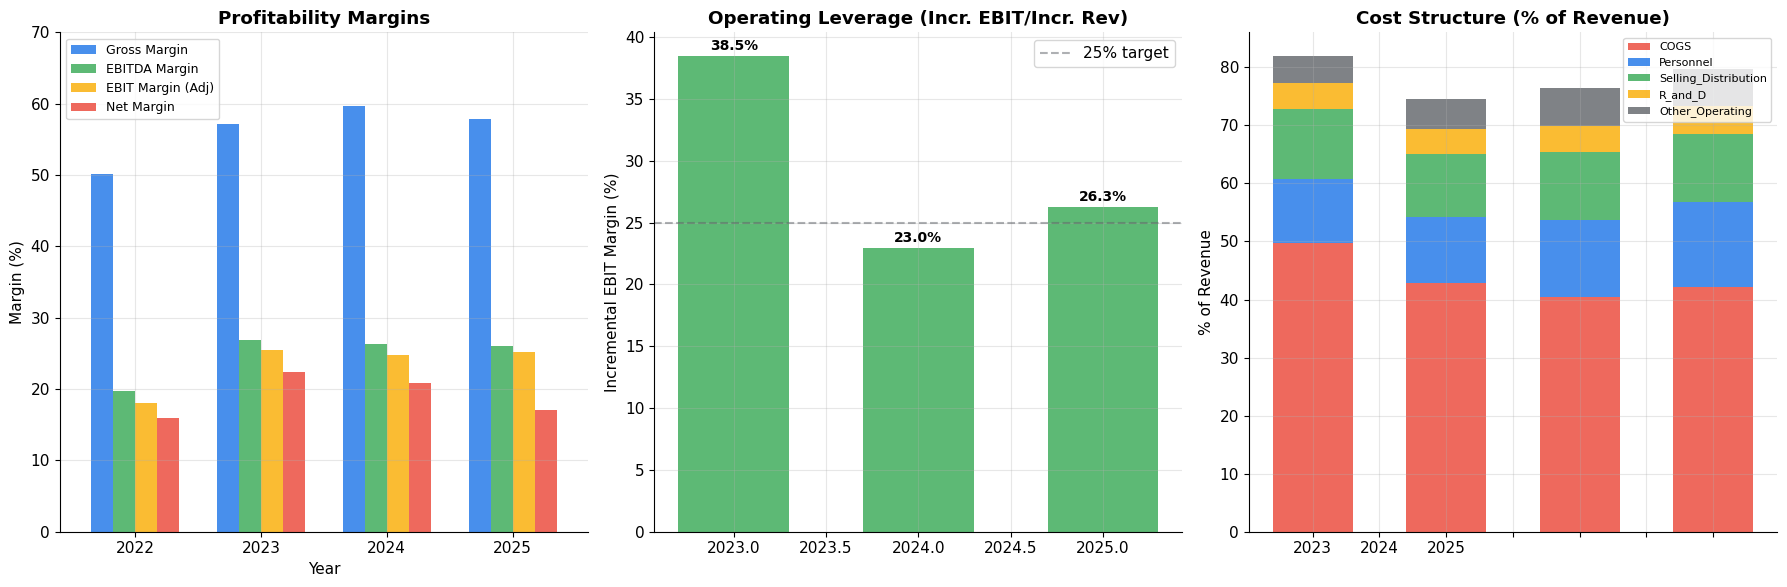

In [9]:
# ── Cell 10: Margin & Operating Leverage Charts ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Margin waterfall
ax1 = axes[0]
margins = pd.DataFrame({
    'Gross Margin': income_stmt['Gross_Margin'],
    'EBITDA Margin': income_stmt['EBITDA_Margin'],
    'EBIT Margin (Adj)': income_stmt['EBIT_Margin_Adj'],
    'Net Margin': income_stmt['Net_Margin'],
})
margins.plot(kind='bar', ax=ax1, color=[COLORS['primary'], COLORS['secondary'],
             COLORS['gold'], COLORS['accent']], alpha=0.8, width=0.7)
ax1.set_ylabel('Margin (%)')
ax1.set_title('Profitability Margins', fontweight='bold')
ax1.set_xticklabels(years, rotation=0)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_ylim(0, 70)

# 2) Operating leverage — incremental EBIT margin
ax2 = axes[1]
incr_rev = income_stmt['Revenue'].diff()
incr_ebit = income_stmt['EBIT_Adjusted'].diff()
incr_margin = (incr_ebit / incr_rev * 100).dropna()
ax2.bar(years[1:], incr_margin, color=COLORS['secondary'], alpha=0.8, width=0.6)
ax2.axhline(y=25, color=COLORS['neutral'], linestyle='--', alpha=0.5, label='25% target')
ax2.set_ylabel('Incremental EBIT Margin (%)')
ax2.set_title('Operating Leverage (Incr. EBIT/Incr. Rev)', fontweight='bold')
for yr, m in zip(years[1:], incr_margin):
    ax2.text(yr, m + 0.5, f'{m:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax2.legend()

# 3) Expense as % of revenue
ax3 = axes[2]
exp_cats = ['COGS', 'Personnel', 'Selling_Distribution', 'R_and_D', 'Other_Operating']
exp_colors = [COLORS['accent'], COLORS['primary'], COLORS['secondary'], COLORS['gold'], COLORS['neutral']]
bottom = np.zeros(len(years))
for cat, col in zip(exp_cats, exp_colors):
    vals = expense_pct[cat]
    ax3.bar(years, vals, bottom=bottom, color=col, alpha=0.8, label=cat, width=0.6)
    bottom += vals.values
ax3.set_ylabel('% of Revenue')
ax3.set_title('Cost Structure (% of Revenue)', fontweight='bold')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_xticklabels(years, rotation=0)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_margins.png', dpi=150, bbox_inches='tight')
plt.show()

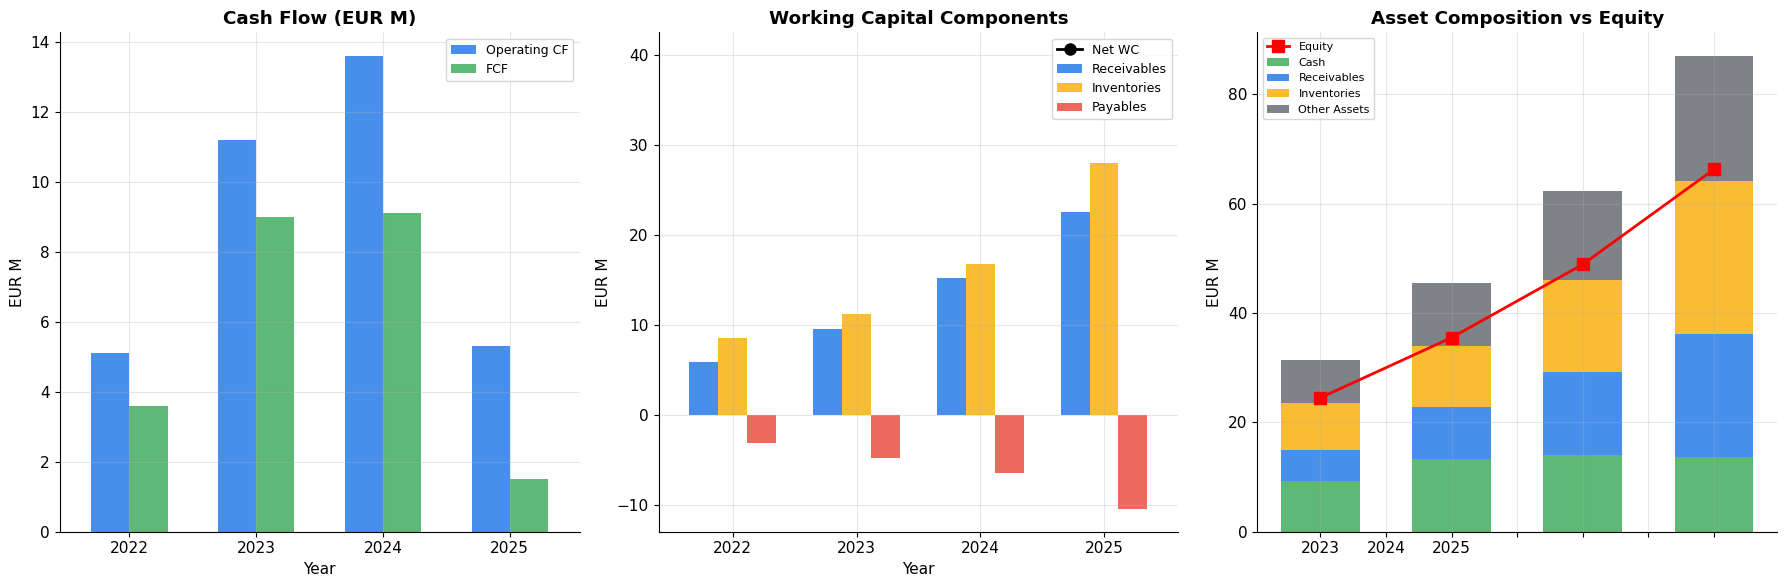

In [10]:
# ── Cell 11: Cash Flow & Balance Sheet Analysis ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Cash flow components
ax1 = axes[0]
cf_items = pd.DataFrame({
    'Operating CF': cash_flow['Operating_CF'] / 1000,
    'Investing CF': cash_flow['Investing_CF'] / 1000,
    'Financing CF': cash_flow['Financing_CF'] / 1000,
    'FCF': cash_flow['FCF'] / 1000,
}, index=years)
cf_items[['Operating CF', 'FCF']].plot(kind='bar', ax=ax1,
    color=[COLORS['primary'], COLORS['secondary']], alpha=0.8, width=0.6)
ax1.set_ylabel('EUR M')
ax1.set_title('Cash Flow (EUR M)', fontweight='bold')
ax1.set_xticklabels(years, rotation=0)
ax1.legend(fontsize=9)

# 2) Working capital build
ax2 = axes[1]
wc = pd.DataFrame({
    'Receivables': balance_sheet['Trade_Receivables'] / 1000,
    'Inventories': balance_sheet['Inventories'] / 1000,
    'Payables': -balance_sheet['Trade_Payables'] / 1000,
}, index=years)
wc['Net WC'] = wc['Receivables'] + wc['Inventories'] + wc['Payables']
colors_wc = [COLORS['primary'], COLORS['gold'], COLORS['accent']]
wc[['Receivables', 'Inventories', 'Payables']].plot(kind='bar', ax=ax2,
    color=colors_wc, alpha=0.8, width=0.7)
ax2.plot(years, wc['Net WC'], 'ko-', markersize=8, linewidth=2, label='Net WC')
ax2.set_ylabel('EUR M')
ax2.set_title('Working Capital Components', fontweight='bold')
ax2.set_xticklabels(years, rotation=0)
ax2.legend(fontsize=9)

# 3) Balance sheet composition
ax3 = axes[2]
bs_comp = pd.DataFrame({
    'Cash': balance_sheet['Cash_Equivalents'] / 1000,
    'Receivables': balance_sheet['Trade_Receivables'] / 1000,
    'Inventories': balance_sheet['Inventories'] / 1000,
    'Other Assets': (balance_sheet['Total_Assets'] - balance_sheet['Cash_Equivalents']
                     - balance_sheet['Trade_Receivables'] - balance_sheet['Inventories']) / 1000,
}, index=years)
bottom = np.zeros(len(years))
colors_bs = [COLORS['secondary'], COLORS['primary'], COLORS['gold'], COLORS['neutral']]
for col, c in zip(bs_comp.columns, colors_bs):
    ax3.bar(years, bs_comp[col], bottom=bottom, color=c, alpha=0.8, label=col, width=0.6)
    bottom += bs_comp[col].values
ax3.plot(years, balance_sheet['Total_Equity'] / 1000, 'rs-', markersize=8, linewidth=2, label='Equity')
ax3.set_ylabel('EUR M')
ax3.set_title('Asset Composition vs Equity', fontweight='bold')
ax3.legend(fontsize=8)
ax3.set_xticklabels(years, rotation=0)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_cashflow_bs.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell Group 3: Bottom-Up Operating Model (15-Year, Three-Phase: 2026-2040)

Shelly is an early-stage compounder (FY22-25 revenue CAGR ~45%) with a large,
underpenetrated smart-home TAM. A 5-year window structurally under-values such a name:
it forces a Gordon-Growth terminal onto a cash flow still growing ~17%, so the terminal
value carries 80%+ of enterprise value off a mid-sprint number.

This model uses an **explicit 15-year, three-phase** structure so the historical
hyper-growth fades gradually to a mature, GDP-like rate **before** the Gordon terminal begins:

- **Phase 1 — Detailed hyper-growth (2026-2030):** bottom-up device shipments x ASP + cloud/subscription.
- **Phase 2 — Transition (2031-2035):** growth decelerates; operating leverage and cloud mix lift margins.
- **Phase 3 — Maturation (2036-2040):** growth converges toward terminal; margins near their structural ceiling.

Growth is faded faster than a pure-software analog to respect hardware cyclicality / ASP
commoditization risk (no large software peer sustained 30%+ for more than ~7-8 years from peak).

In [11]:
# ── Cell 13: Bottom-Up Model Assumptions (15-Year, Three-Phase) ─────────────

# Horizon: 2026-2040 (15 explicit years). Phase 1: idx 0-4 | Phase 2: 5-9 | Phase 3: 10-14
proj_years = list(range(2026, 2041))
N_PROJ = len(proj_years)

# Each driver is a 15-element PATH. ASP and cloud are modeled as GROWTH rates
# (compounded off a base) rather than absolute levels, so the fade is explicit.
scenarios = {
    'Bull': {
        'device_growth': [0.35,0.30,0.27,0.24,0.21, 0.18,0.16,0.14,0.12,0.10, 0.08,0.07,0.06,0.05,0.045],
        'asp_growth':    [0.03,0.02,0.02,0.02,0.02, 0.015,0.015,0.012,0.012,0.010, 0.008,0.006,0.006,0.005,0.005],
        'cloud_growth':  [None,1.20,1.10,0.85,0.65, 0.52,0.44,0.38,0.32,0.27, 0.22,0.18,0.15,0.13,0.11],
        'cloud_yr1_K':   1_500,
        'gross_margin':  [58.0,58.3,58.6,58.9,59.1, 59.3,59.5,59.6,59.7,59.8, 59.9,60.0,60.0,60.0,60.0],
        'opex_pct':      [33.0,32.0,31.0,30.3,29.7, 29.2,28.8,28.4,28.1,27.9, 27.7,27.6,27.5,27.5,27.5],
        'sbc_K':         [5_000,4_000,3_000,2_000,1_500, 1_500,1_500,1_500,1_500,1_500, 1_500,1_500,1_500,1_500,1_500],
        'tax_rate':0.10,'da_pct_rev':0.018,'capex_pct_rev':0.025,'nwc_pct_rev':0.27,'term_roic':0.24,
        'label':'Bull',
    },
    'Base': {
        'device_growth': [0.28,0.24,0.21,0.18,0.16, 0.14,0.12,0.10,0.08,0.07, 0.06,0.05,0.045,0.04,0.035],
        'asp_growth':    [0.02,0.01,0.014,0.014,0.014, 0.012,0.010,0.010,0.008,0.008, 0.006,0.005,0.005,0.004,0.004],
        'cloud_growth':  [None,1.08,1.00,0.70,0.53, 0.42,0.34,0.28,0.24,0.20, 0.17,0.14,0.12,0.10,0.09],
        'cloud_yr1_K':   1_200,
        'gross_margin':  [57.5,57.5,57.6,57.8,58.0, 58.1,58.2,58.3,58.4,58.5, 58.5,58.5,58.5,58.5,58.5],
        'opex_pct':      [33.0,32.6,32.2,31.8,31.5, 31.2,31.0,30.8,30.6,30.5, 30.4,30.3,30.2,30.0,30.0],
        'sbc_K':         [5_000,4_000,3_000,2_500,2_000, 1_800,1_700,1_600,1_500,1_500, 1_500,1_500,1_500,1_500,1_500],
        'tax_rate':0.10,'da_pct_rev':0.018,'capex_pct_rev':0.025,'nwc_pct_rev':0.28,'term_roic':0.20,
        'label':'Base',
    },
    'Bear': {
        'device_growth': [0.20,0.15,0.12,0.10,0.08, 0.07,0.06,0.05,0.04,0.035, 0.03,0.03,0.025,0.025,0.02],
        'asp_growth':    [0.0,0.0,0.0,0.0,0.0, 0.0,0.0,0.0,0.0,0.0, 0.0,0.0,0.0,0.0,0.0],
        'cloud_growth':  [None,0.88,0.67,0.60,0.50, 0.40,0.30,0.25,0.20,0.17, 0.14,0.12,0.10,0.08,0.07],
        'cloud_yr1_K':   800,
        'gross_margin':  [56.5,56.0,55.8,55.5,55.5, 55.3,55.2,55.0,55.0,55.0, 55.0,55.0,55.0,55.0,55.0],
        'opex_pct':      [34.0,33.5,33.2,33.0,33.0, 32.8,32.6,32.5,32.4,32.3, 32.2,32.1,32.0,32.0,32.0],
        'sbc_K':         [6_000,5_000,4_000,3_500,3_000, 2_800,2_600,2_400,2_200,2_000, 2_000,2_000,2_000,2_000,2_000],
        'tax_rate':0.10,'da_pct_rev':0.020,'capex_pct_rev':0.028,'nwc_pct_rev':0.30,'term_roic':0.15,
        'label':'Bear',
    },
}

def _phase(i):
    return 'P1 (hyper)' if i < 5 else ('P2 (transition)' if i < 10 else 'P3 (maturation)')

print('=' * 88)
print('SCENARIO ASSUMPTIONS — 15-YEAR THREE-PHASE (2026-2040)')
print('=' * 88)
for name, s in scenarios.items():
    print(f'\n--- {name} Case (terminal ROIC {s["term_roic"]*100:.0f}%) ---')
    print(f'  Device growth: {[f"{g*100:.0f}%" for g in s["device_growth"]]}')
    print(f'  Gross margin:  {s["gross_margin"][0]:.1f}% -> {s["gross_margin"][-1]:.1f}%')
    print(f'  OpEx % rev:    {s["opex_pct"][0]:.1f}% -> {s["opex_pct"][-1]:.1f}%')
    print(f'  Phase map: yr1-5 {_phase(0)} | yr6-10 {_phase(5)} | yr11-15 {_phase(10)}')

SCENARIO ASSUMPTIONS — 15-YEAR THREE-PHASE (2026-2040)

--- Bull Case (terminal ROIC 24%) ---
  Device growth: ['35%', '30%', '27%', '24%', '21%', '18%', '16%', '14%', '12%', '10%', '8%', '7%', '6%', '5%', '4%']
  Gross margin:  58.0% -> 60.0%
  OpEx % rev:    33.0% -> 27.5%
  Phase map: yr1-5 P1 (hyper) | yr6-10 P2 (transition) | yr11-15 P3 (maturation)

--- Base Case (terminal ROIC 20%) ---
  Device growth: ['28%', '24%', '21%', '18%', '16%', '14%', '12%', '10%', '8%', '7%', '6%', '5%', '4%', '4%', '4%']
  Gross margin:  57.5% -> 58.5%
  OpEx % rev:    33.0% -> 30.0%
  Phase map: yr1-5 P1 (hyper) | yr6-10 P2 (transition) | yr11-15 P3 (maturation)

--- Bear Case (terminal ROIC 15%) ---
  Device growth: ['20%', '15%', '12%', '10%', '8%', '7%', '6%', '5%', '4%', '4%', '3%', '3%', '2%', '2%', '2%']
  Gross margin:  56.5% -> 55.0%
  OpEx % rev:    34.0% -> 32.0%
  Phase map: yr1-5 P1 (hyper) | yr6-10 P2 (transition) | yr11-15 P3 (maturation)


In [12]:
# ── Cell 14: Build Projections for All Scenarios (15-Year) ──────────────

def build_projections(scenario, base_devices_M=11.0, base_rev_K=149_700,
                      base_nwc_K=40_000, base_asp_eur=14.0):
    """Bottom-up 15-year projection. ASP and cloud compound off a base via growth paths.
    FCF is SBC-EXPENSED: NOPAT is taken on reported EBIT (after management SBC), and SBC
    is NOT added back. Equity value is later divided by the CURRENT diluted share count."""
    s = scenario
    results = []
    prev_devices = base_devices_M
    prev_nwc = base_nwc_K
    prev_asp = base_asp_eur
    prev_cloud = None
    prev_rev = base_rev_K

    for i, yr in enumerate(proj_years):
        devices_M = prev_devices * (1 + s['device_growth'][i])
        asp_eur = prev_asp * (1 + s['asp_growth'][i])
        hw_rev_K = devices_M * 1_000 * asp_eur

        cloud_rev_K = s['cloud_yr1_K'] if i == 0 else prev_cloud * (1 + s['cloud_growth'][i])
        total_rev_K = hw_rev_K + cloud_rev_K

        hw_gm = s['gross_margin'][i] / 100
        cloud_gm = 0.90
        gross_profit_K = hw_rev_K * hw_gm + cloud_rev_K * cloud_gm
        blended_gm = gross_profit_K / total_rev_K * 100

        opex_K = total_rev_K * s['opex_pct'][i] / 100
        mgmt_sbc_K = s['sbc_K'][i]
        ebit_adj_K = gross_profit_K - opex_K
        ebit_reported_K = ebit_adj_K - mgmt_sbc_K

        da_K = total_rev_K * s['da_pct_rev']
        ebitda_K = ebit_adj_K + da_K
        net_income_K = ebit_reported_K * (1 - s['tax_rate'])

        capex_K = total_rev_K * s['capex_pct_rev']
        nwc_K = total_rev_K * s['nwc_pct_rev']
        delta_nwc_K = nwc_K - prev_nwc

        # Unlevered FCF — SBC EXPENSED: NOPAT on REPORTED (after-SBC) EBIT
        nopat_K = ebit_reported_K * (1 - s['tax_rate'])
        fcf_K = nopat_K + da_K - capex_K - delta_nwc_K

        results.append({
            'Year': yr, 'Phase': 1 if i < 5 else (2 if i < 10 else 3),
            'Devices_M': devices_M, 'ASP_EUR': asp_eur,
            'HW_Rev_K': hw_rev_K, 'Cloud_Rev_K': cloud_rev_K, 'Revenue_K': total_rev_K,
            'Rev_Growth_Pct': (total_rev_K / prev_rev - 1) * 100,
            'Gross_Profit_K': gross_profit_K, 'Blended_GM_Pct': blended_gm,
            'OpEx_K': opex_K, 'Mgmt_SBC_K': mgmt_sbc_K,
            'EBIT_Adj_K': ebit_adj_K, 'EBIT_Margin_Adj_Pct': ebit_adj_K / total_rev_K * 100,
            'EBIT_Reported_K': ebit_reported_K, 'EBITDA_K': ebitda_K, 'DA_K': da_K,
            'Net_Income_K': net_income_K, 'Capex_K': capex_K, 'NWC_K': nwc_K,
            'Delta_NWC_K': delta_nwc_K, 'NOPAT_K': nopat_K, 'FCF_K': fcf_K,
            'FCF_Margin_Pct': fcf_K / total_rev_K * 100,
            'Cloud_Pct': cloud_rev_K / total_rev_K * 100,
        })
        prev_devices = devices_M; prev_asp = asp_eur; prev_cloud = cloud_rev_K
        prev_nwc = nwc_K; prev_rev = total_rev_K

    return pd.DataFrame(results).set_index('Year')

projections = {}
for name, s in scenarios.items():
    projections[name] = build_projections(s)

base = projections['Base']
show_cols = ['Revenue_K', 'Rev_Growth_Pct', 'Blended_GM_Pct', 'EBIT_Adj_K',
             'EBIT_Margin_Adj_Pct', 'Net_Income_K', 'FCF_K', 'Cloud_Pct', 'Devices_M']
print('=' * 88)
print('BASE CASE PROJECTION (2026-2040)')
print('=' * 88)
disp = base[show_cols].copy()
for c in ['Revenue_K', 'EBIT_Adj_K', 'Net_Income_K', 'FCF_K']:
    disp[c] = disp[c] / 1000
print(disp.to_string(float_format=lambda x: f'{x:,.1f}'))
print(f"\n15-yr revenue CAGR (2025->2040): "
      f"{((base.loc[2040,'Revenue_K']/149_700)**(1/15)-1)*100:.1f}%")
print(f"2040 revenue growth: {base.loc[2040,'Rev_Growth_Pct']:.1f}%  |  "
      f"terminal EBIT margin: {base.loc[2040,'EBIT_Margin_Adj_Pct']:.1f}%")

BASE CASE PROJECTION (2026-2040)
      Revenue_K  Rev_Growth_Pct  Blended_GM_Pct  EBIT_Adj_K  EBIT_Margin_Adj_Pct  Net_Income_K  FCF_K  Cloud_Pct  Devices_M
Year                                                                                                                       
2026      202.3            35.1            57.7        49.9                 24.7          40.4   22.4        0.6       14.1
2027      254.3            25.7            57.8        64.1                 25.2          54.1   37.8        1.0       17.5
2028      313.9            23.5            58.1        81.4                 25.9          70.5   51.6        1.6       21.1
2029      378.2            20.5            58.5       101.1                 26.7          88.7   68.1        2.2       24.9
2030      447.8            18.4            58.9       122.8                 27.4         108.7   86.1        2.9       28.9
2031      520.1            16.1            59.2       145.8                 28.0         129.6  105

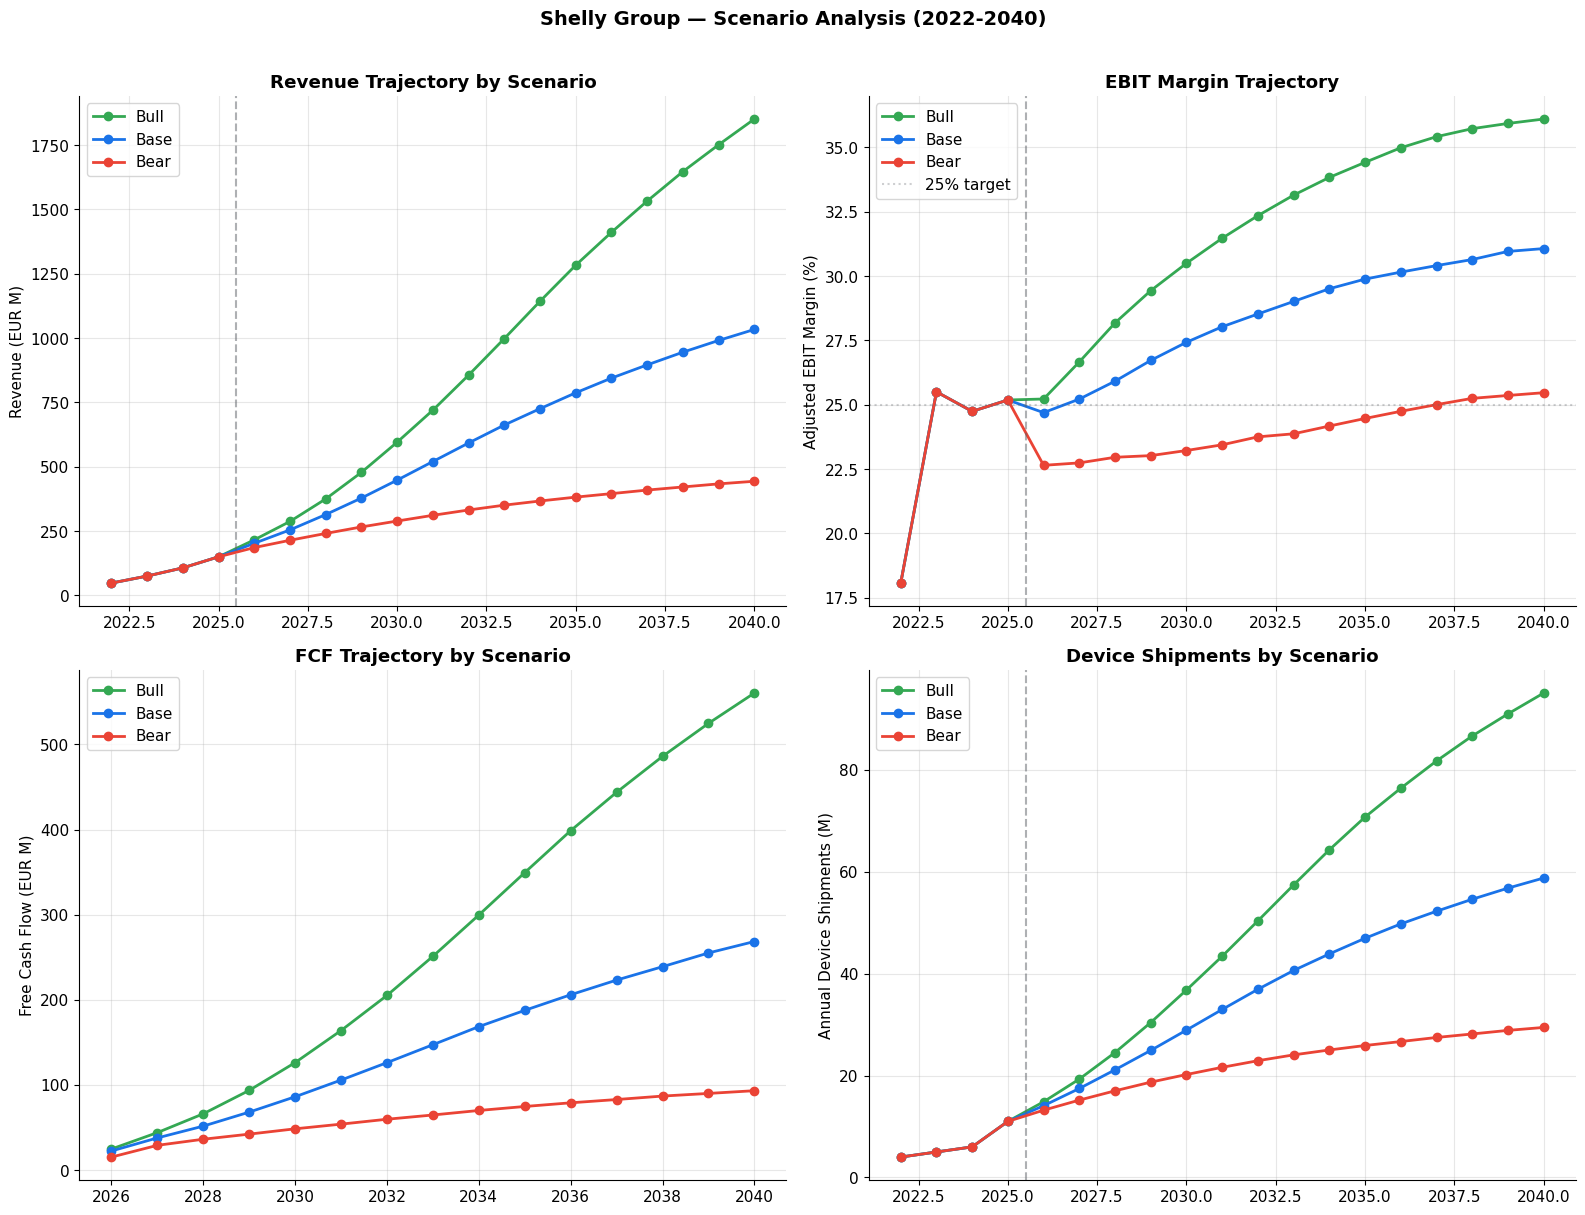

In [13]:
# ── Cell 15: Scenario Comparison Charts ──────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# 1) Revenue trajectory
ax = axes[0, 0]
# Add historical
hist_rev = income_stmt['Revenue'] / 1000
for name, proj in projections.items():
    combined = pd.concat([hist_rev, proj['Revenue_K'] / 1000])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.set_ylabel('Revenue (EUR M)')
ax.set_title('Revenue Trajectory by Scenario', fontweight='bold')
ax.legend()

# 2) EBIT margin
ax = axes[0, 1]
hist_ebit_m = income_stmt['EBIT_Margin_Adj']
for name, proj in projections.items():
    combined = pd.concat([hist_ebit_m, proj['EBIT_Margin_Adj_Pct']])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.axhline(y=25, color=COLORS['neutral'], linestyle=':', alpha=0.3, label='25% target')
ax.set_ylabel('Adjusted EBIT Margin (%)')
ax.set_title('EBIT Margin Trajectory', fontweight='bold')
ax.legend()

# 3) FCF
ax = axes[1, 0]
for name, proj in projections.items():
    ax.plot(proj_years, proj['FCF_K'] / 1000, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.set_ylabel('Free Cash Flow (EUR M)')
ax.set_title('FCF Trajectory by Scenario', fontweight='bold')
ax.legend()

# 4) Device shipments
ax = axes[1, 1]
hist_dev = kpi_data['Devices_Shipped_Annual_M']
for name, proj in projections.items():
    combined = pd.concat([hist_dev, proj['Devices_M']])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.set_ylabel('Annual Device Shipments (M)')
ax.set_title('Device Shipments by Scenario', fontweight='bold')
ax.legend()

plt.suptitle('Shelly Group — Scenario Analysis (2022-2040)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Cell 16: Product/Geographic Growth Matrix (illustrative, 15-yr) ─────────

print('=' * 80)
print('GEOGRAPHIC REVENUE GROWTH MATRIX — BASE CASE (EUR M, illustrative)')
print('=' * 80)

# Illustrative geographic split (independent of the device x ASP build above).
# DACH matures first; Rest-of-World (incl. US) compounds fastest, then fades.
geo_growth = {
    'DACH':           [0.20,0.18,0.16,0.14,0.12, 0.10,0.09,0.08,0.07,0.06, 0.05,0.045,0.04,0.035,0.03],
    'Rest_of_Europe': [0.35,0.32,0.28,0.25,0.22, 0.19,0.16,0.14,0.12,0.10, 0.08,0.07,0.06,0.05,0.045],
    'Rest_of_World':  [0.50,0.45,0.40,0.35,0.30, 0.26,0.22,0.19,0.16,0.14, 0.11,0.09,0.08,0.07,0.06],
}

geo_proj = pd.DataFrame(index=proj_years)
base_geo = {'DACH': 62_000, 'Rest_of_Europe': 74_000, 'Rest_of_World': 13_700}
for region in base_geo:
    vals, prev = [], base_geo[region]
    for i, yr in enumerate(proj_years):
        prev = prev * (1 + geo_growth[region][i]); vals.append(prev)
    geo_proj[region] = vals
geo_proj['Total'] = geo_proj.sum(axis=1)

# Show every 5th year to keep the table readable across 15 years
show_years = [2026, 2030, 2035, 2040]
print((geo_proj.loc[show_years] / 1000).to_string(float_format=lambda x: f'{x:.1f}'))
print()
geo_mix = geo_proj[list(base_geo)].div(geo_proj['Total'], axis=0) * 100
print('GEOGRAPHIC MIX (%) — BASE CASE (selected years)')
print(geo_mix.loc[show_years].to_string(float_format=lambda x: f'{x:.1f}%'))

print('\nCLOUD/SUBSCRIPTION REVENUE AS %% OF TOTAL — ALL SCENARIOS (selected years)'.replace('%%','%'))
for name in ['Bull', 'Base', 'Bear']:
    pct = projections[name]['Cloud_Pct']
    print(f'  {name:5s}: ' + '  '.join([f'{yr}: {pct.loc[yr]:.1f}%' for yr in show_years]))

GEOGRAPHIC REVENUE GROWTH MATRIX — BASE CASE (EUR M, illustrative)
      DACH  Rest_of_Europe  Rest_of_World  Total
2026  74.4            99.9           20.6  194.8
2030 130.0           257.4           73.2  460.6
2035 191.0           499.0          177.1  867.1
2040 232.3           670.7          262.5 1165.5

GEOGRAPHIC MIX (%) — BASE CASE (selected years)
      DACH  Rest_of_Europe  Rest_of_World
2026 38.2%           51.3%          10.5%
2030 28.2%           55.9%          15.9%
2035 22.0%           57.6%          20.4%
2040 19.9%           57.5%          22.5%

CLOUD/SUBSCRIPTION REVENUE AS % OF TOTAL — ALL SCENARIOS (selected years)
  Bull : 2026: 0.7%  2030: 3.6%  2035: 8.3%  2040: 12.0%
  Base : 2026: 0.6%  2030: 2.9%  2035: 6.0%  2040: 8.2%
  Bear : 2026: 0.4%  2030: 2.1%  2035: 5.0%  2040: 7.0%


# Cell Group 4: 3-Statement Projected Model (2026-2040)

Full income statement, balance sheet, and cash flow projections for the Base case across
the 15-year horizon. Cross-checked with Bull and Bear scenarios for key metrics.

In [15]:
# ── Cell 18: 3-Statement Projected Model (Base Case) ────────

base_proj = projections['Base']
sbc_base = scenarios['Base']['sbc_K']

# --- Projected Income Statement ---
proj_is = pd.DataFrame(index=proj_years)
proj_is['Revenue'] = base_proj['Revenue_K']
proj_is['COGS'] = base_proj['Revenue_K'] - base_proj['Gross_Profit_K']
proj_is['Gross_Profit'] = base_proj['Gross_Profit_K']
proj_is['Gross_Margin_%'] = base_proj['Blended_GM_Pct']
proj_is['OpEx'] = base_proj['OpEx_K']
proj_is['Mgmt_SBC'] = base_proj['Mgmt_SBC_K']
proj_is['EBIT_Adj'] = base_proj['EBIT_Adj_K']
proj_is['EBIT_Reported'] = base_proj['EBIT_Reported_K']
proj_is['EBIT_Margin_Adj_%'] = base_proj['EBIT_Margin_Adj_Pct']
proj_is['D_and_A'] = base_proj['DA_K']
proj_is['EBITDA'] = base_proj['EBITDA_K']
proj_is['Tax_10pct'] = base_proj['EBIT_Reported_K'] * 0.10
proj_is['Net_Income'] = base_proj['Net_Income_K']
proj_is['EPS'] = base_proj['Net_Income_K'] / 18_900  # diluted shares ~18.9M

print('=' * 80)
print('PROJECTED INCOME STATEMENT — BASE CASE (EUR K) — selected years')
print('=' * 80)
sel = [2026, 2030, 2035, 2040]
print(proj_is.loc[sel].T.to_string(float_format=lambda x: f'{x:,.1f}'))

# --- Projected Balance Sheet ---
proj_bs = pd.DataFrame(index=proj_years)
prev_cash = 13_600
prev_equity = 66_300
for i, yr in enumerate(proj_years):
    rev = base_proj.loc[yr, 'Revenue_K']; ni = base_proj.loc[yr, 'Net_Income_K']
    capex = base_proj.loc[yr, 'Capex_K']; da = base_proj.loc[yr, 'DA_K']
    ocf = ni + da + sbc_base[i] - base_proj.loc[yr, 'Delta_NWC_K']
    div = min(ni * 0.10, 5_000)
    cash = prev_cash + (ocf - capex) - div
    proj_bs.loc[yr, 'Cash'] = cash
    proj_bs.loc[yr, 'Receivables'] = rev * 0.15
    proj_bs.loc[yr, 'Inventories'] = rev * 0.17
    proj_bs.loc[yr, 'Other_Current'] = rev * 0.03
    proj_bs.loc[yr, 'Total_Current'] = cash + rev * 0.35
    proj_bs.loc[yr, 'PP_E'] = 7_200 + capex * (i + 1) - da * (i + 1) * 0.5
    proj_bs.loc[yr, 'Intangibles'] = 6_500 + 1_500 * (i + 1)
    proj_bs.loc[yr, 'Total_Assets'] = proj_bs.loc[yr, 'Total_Current'] + proj_bs.loc[yr, 'PP_E'] + proj_bs.loc[yr, 'Intangibles'] + 5_000
    proj_bs.loc[yr, 'Total_Liabilities'] = rev * 0.14
    proj_bs.loc[yr, 'Equity'] = prev_equity + ni - div + sbc_base[i]
    proj_bs.loc[yr, 'Equity_Ratio_%'] = proj_bs.loc[yr, 'Equity'] / proj_bs.loc[yr, 'Total_Assets'] * 100
    prev_cash = cash; prev_equity = proj_bs.loc[yr, 'Equity']

print('\n' + '=' * 80)
print('PROJECTED BALANCE SHEET — BASE CASE (EUR K) — selected years')
print('=' * 80)
print(proj_bs.loc[sel].T.to_string(float_format=lambda x: f'{x:,.1f}'))

PROJECTED INCOME STATEMENT — BASE CASE (EUR K) — selected years
                       2026      2030      2035        2040
Revenue           202,262.4 447,807.8 787,310.3 1,033,496.8
COGS               85,571.5 183,924.4 311,910.9   402,351.5
Gross_Profit      116,690.9 263,883.5 475,399.4   631,145.3
Gross_Margin_%         57.7      58.9      60.4        61.1
OpEx               66,746.6 141,059.5 240,129.6   310,049.0
Mgmt_SBC            5,000.0   2,000.0   1,500.0     1,500.0
EBIT_Adj           49,944.3 122,824.0 235,269.7   321,096.3
EBIT_Reported      44,944.3 120,824.0 233,769.7   319,596.3
EBIT_Margin_Adj_%      24.7      27.4      29.9        31.1
D_and_A             3,640.7   8,060.5  14,171.6    18,602.9
EBITDA             53,585.0 130,884.6 249,441.3   339,699.2
Tax_10pct           4,494.4  12,082.4  23,377.0    31,959.6
Net_Income         40,449.9 108,741.6 210,392.8   287,636.6
EPS                     2.1       5.8      11.1        15.2

PROJECTED BALANCE SHEET — BASE CASE

In [16]:
# ── Cell 19: Cash Flow Statement & Verification ─────────

proj_cf = pd.DataFrame(index=proj_years)
proj_cf['Net_Income'] = base_proj['Net_Income_K']
proj_cf['D_and_A'] = base_proj['DA_K']
proj_cf['SBC_NonCash'] = base_proj['Mgmt_SBC_K']
proj_cf['Delta_WC'] = -base_proj['Delta_NWC_K']
proj_cf['Operating_CF'] = proj_cf['Net_Income'] + proj_cf['D_and_A'] + proj_cf['SBC_NonCash'] + proj_cf['Delta_WC']
proj_cf['Capex'] = -base_proj['Capex_K']
proj_cf['FCF'] = proj_cf['Operating_CF'] + proj_cf['Capex']
proj_cf['Dividends'] = [-min(ni * 0.10, 5_000) for ni in base_proj['Net_Income_K']]
proj_cf['Net_Cash_Change'] = proj_cf['FCF'] + proj_cf['Dividends']

print('=' * 80)
print('PROJECTED CASH FLOW STATEMENT — BASE CASE (EUR K) — selected years')
print('=' * 80)
print(proj_cf.loc[[2026,2030,2035,2040]].T.to_string(float_format=lambda x: f'{x:,.1f}'))

# Note: this statement's FCF adds SBC back as a non-cash item and is the *accounting/liquidity*
# view. The DCF (Cell 21) uses an SBC-EXPENSED unlevered FCF (NOPAT on reported EBIT).
print('\n' + '=' * 60)
print('VERIFICATION CHECKS (every year)')
print('=' * 60)
for yr in proj_years:
    print(f'  {yr}: Rev={base_proj.loc[yr,"Revenue_K"]/1000:>6,.0f}M  '
          f'g={base_proj.loc[yr,"Rev_Growth_Pct"]:>5.1f}%  '
          f'GM={base_proj.loc[yr,"Blended_GM_Pct"]:.1f}%  '
          f'EBIT_m={base_proj.loc[yr,"EBIT_Margin_Adj_Pct"]:.1f}%  '
          f'unlev.FCF={base_proj.loc[yr,"FCF_K"]/1000:>6,.1f}M')
print(f'\n  Cumulative unlevered FCF (2026-2040): EUR {base_proj["FCF_K"].sum()/1000:,.0f}M')
print(f'  Ending Cash (2040): EUR {proj_bs.loc[2040, "Cash"]/1000:,.0f}M')
print(f'  Ending Equity (2040): EUR {proj_bs.loc[2040, "Equity"]/1000:,.0f}M')

PROJECTED CASH FLOW STATEMENT — BASE CASE (EUR K) — selected years
                     2026      2030      2035      2040
Net_Income       40,449.9 108,741.6 210,392.8 287,636.6
D_and_A           3,640.7   8,060.5  14,171.6  18,602.9
SBC_NonCash       5,000.0   2,000.0   1,500.0   1,500.0
Delta_WC        -16,633.5 -19,501.7 -17,293.2 -11,959.4
Operating_CF     32,457.1  99,300.5 208,771.2 295,780.2
Capex            -5,056.6 -11,195.2 -19,682.8 -25,837.4
FCF              27,400.6  88,105.3 189,088.4 269,942.8
Dividends        -4,045.0  -5,000.0  -5,000.0  -5,000.0
Net_Cash_Change  23,355.6  83,105.3 184,088.4 264,942.8

VERIFICATION CHECKS (every year)
  2026: Rev=   202M  g= 35.1%  GM=57.7%  EBIT_m=24.7%  unlev.FCF=  22.4M
  2027: Rev=   254M  g= 25.7%  GM=57.8%  EBIT_m=25.2%  unlev.FCF=  37.8M
  2028: Rev=   314M  g= 23.5%  GM=58.1%  EBIT_m=25.9%  unlev.FCF=  51.6M
  2029: Rev=   378M  g= 20.5%  GM=58.5%  EBIT_m=26.7%  unlev.FCF=  68.1M
  2030: Rev=   448M  g= 18.4%  GM=58.9%  EBIT_m

# Cell Group 5: DCF Valuation (15-Year, Three-Phase)

Discounted Cash Flow on **SBC-expensed** unlevered free cash flow
(NOPAT on reported EBIT + D&A − Capex − ΔNWC), summed over the explicit 15-year horizon.

Key parameters:
- **WACC**: 10.0% (CAPM with small-cap premium; net-cash balance sheet, no debt adjustment)
- **Terminal growth**: 3.0% (long-term nominal GDP), applied only at year 15 (2040)
- **Terminal value — Damodaran convergence:** reinvestment is tied to a sustainable terminal
  return, `reinvestment_rate = g / ROIC_terminal`, so
  `TV = NOPAT_2040 × (1+g) × (1 − g/ROIC_terminal) / (WACC − g)`.
  This avoids the naïve-Gordon trap of carrying growth-era capex into perpetuity.
- **SBC**: expensed in the cash flows (NOT added back); equity value ÷ **current** 18.9M diluted shares.
- The implied **terminal EV/EBITDA** is printed as a mandatory sanity check.

In [17]:
# ── Cell 21: DCF Valuation Function & Execution (Damodaran terminal) ────────

def dcf_valuation(proj_df, wacc=0.10, terminal_growth=0.03, term_roic=0.20,
                  net_cash_K=13_600, diluted_shares_M=18.9, label=''):
    """15-year DCF on SBC-expensed unlevered FCF, with a Damodaran-convergence terminal
    value (reinvestment tied to terminal ROIC)."""
    fcf = proj_df['FCF_K'].values
    years_out = np.arange(1, len(fcf) + 1)
    discount_factors = (1 + wacc) ** years_out
    pv_fcfs = fcf / discount_factors
    pv_fcf_total = pv_fcfs.sum()

    # Terminal value — Damodaran convergence off terminal-year NOPAT
    nopat_T = proj_df['NOPAT_K'].values[-1]
    reinvestment_rate = terminal_growth / term_roic
    terminal_value = nopat_T * (1 + terminal_growth) * (1 - reinvestment_rate) / (wacc - terminal_growth)
    pv_terminal = terminal_value / discount_factors[-1]

    ev = pv_fcf_total + pv_terminal
    equity_value = ev + net_cash_K
    price_per_share = equity_value / (diluted_shares_M * 1000)

    ebitda_T = proj_df['EBITDA_K'].values[-1]
    ebit_T = proj_df['EBIT_Adj_K'].values[-1]
    return {
        'label': label, 'PV_FCFs_K': pv_fcf_total, 'Terminal_Value_K': terminal_value,
        'PV_Terminal_K': pv_terminal, 'TV_Pct_of_EV': pv_terminal / ev * 100,
        'Reinvest_Rate': reinvestment_rate,
        'Implied_TV_EV_EBITDA': terminal_value / ebitda_T,
        'Implied_TV_EV_EBIT': terminal_value / ebit_T,
        'Enterprise_Value_K': ev, 'Net_Cash_K': net_cash_K, 'Equity_Value_K': equity_value,
        'Diluted_Shares_M': diluted_shares_M, 'Implied_Price': price_per_share,
        'WACC': wacc, 'Terminal_Growth': terminal_growth, 'Term_ROIC': term_roic,
    }

print('=' * 80)
print('DCF VALUATION — ALL SCENARIOS (15-year, three-phase)')
print('=' * 80)
dcf_results = {}
for name, proj in projections.items():
    dcf = dcf_valuation(proj, term_roic=scenarios[name]['term_roic'], label=name)
    dcf_results[name] = dcf
    print(f'\n--- {name} Case (terminal ROIC {dcf["Term_ROIC"]*100:.0f}%, '
          f'reinvest {dcf["Reinvest_Rate"]*100:.0f}%) ---')
    print(f'  PV of FCFs (2026-2040):    EUR {dcf["PV_FCFs_K"]/1000:,.0f}M')
    print(f'  PV of Terminal Value:      EUR {dcf["PV_Terminal_K"]/1000:,.0f}M')
    print(f'  Terminal Value %% of EV:    {dcf["TV_Pct_of_EV"]:.0f}%'.replace('%%','%'))
    print(f'  Implied terminal EV/EBITDA: {dcf["Implied_TV_EV_EBITDA"]:.1f}x  '
          f'(EV/EBIT {dcf["Implied_TV_EV_EBIT"]:.1f}x)  <- sanity check')
    print(f'  Enterprise Value:          EUR {dcf["Enterprise_Value_K"]/1000:,.0f}M')
    print(f'  + Net Cash:                EUR {dcf["Net_Cash_K"]/1000:,.0f}M')
    print(f'  = Equity Value:            EUR {dcf["Equity_Value_K"]/1000:,.0f}M')
    print(f'  *** Implied Price:         EUR {dcf["Implied_Price"]:.2f} ***')

current_price = 57.60
print(f'\n{"=" * 60}')
print(f'Current Price: EUR {current_price:.2f}')
print(f'{"=" * 60}')
for name in ['Bull', 'Base', 'Bear']:
    implied = dcf_results[name]['Implied_Price']
    print(f'  {name:5s} Implied: EUR {implied:7.2f}  |  Upside: {(implied/current_price-1)*100:+.1f}%')

DCF VALUATION — ALL SCENARIOS (15-year, three-phase)

--- Bull Case (terminal ROIC 24%, reinvest 12%) ---
  PV of FCFs (2026-2040):    EUR 1,522M
  PV of Terminal Value:      EUR 1,850M
  Terminal Value % of EV:    55%
  Implied terminal EV/EBITDA: 11.0x  (EV/EBIT 11.6x)  <- sanity check
  Enterprise Value:          EUR 3,372M
  + Net Cash:                EUR 14M
  = Equity Value:            EUR 3,385M
  *** Implied Price:         EUR 179.11 ***

--- Base Case (terminal ROIC 20%, reinvest 15%) ---
  PV of FCFs (2026-2040):    EUR 871M
  PV of Terminal Value:      EUR 861M
  Terminal Value % of EV:    50%
  Implied terminal EV/EBITDA: 10.6x  (EV/EBIT 11.2x)  <- sanity check
  Enterprise Value:          EUR 1,732M
  + Net Cash:                EUR 14M
  = Equity Value:            EUR 1,746M
  *** Implied Price:         EUR 92.38 ***

--- Bear Case (terminal ROIC 15%, reinvest 20%) ---
  PV of FCFs (2026-2040):    EUR 399M
  PV of Terminal Value:      EUR 281M
  Terminal Value % of EV:    

# Cell Group 6: Sensitivity Analysis & Output

WACC vs. terminal-growth sensitivity, a **year-5 (2030) exit-multiple cross-check** (a
deliberate floor — it discards the post-2030 runway, so it reads below the 15-year DCF),
scenario summary, peer multiples, and the final dashboard.

In [18]:
# ── Cell 23: Sensitivity + Year-5 Exit-Multiple Cross-Check ──

wacc_range = [0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14]
tg_range = [0.02, 0.025, 0.03, 0.035, 0.04]
_troic = scenarios['Base']['term_roic']

sensitivity = pd.DataFrame(index=[f'{w*100:.0f}%' for w in wacc_range],
                           columns=[f'{tg*100:.1f}%' for tg in tg_range])
for wi, w in enumerate(wacc_range):
    for ti, tg in enumerate(tg_range):
        d = dcf_valuation(projections['Base'], wacc=w, terminal_growth=tg, term_roic=_troic)
        sensitivity.iloc[wi, ti] = f'{d["Implied_Price"]:.2f}'

print('=' * 80)
print('PRICE SENSITIVITY — BASE CASE (EUR/share) | Rows: WACC | Cols: Terminal Growth')
print('=' * 80)
print(sensitivity.to_string())
print(f'\nCurrent Price: EUR {current_price:.2f}   '
      f'Base Case (10% WACC, 3.0% TG): EUR {dcf_results["Base"]["Implied_Price"]:.2f}')

# ── Year-5 (2030) exit-multiple cross-check ─────────────────
# Sell-in-2030 value = (2030 EBITDA x exit multiple + net cash), discounted 5yr to today,
# PLUS the PV of 2026-2030 interim FCF. This intentionally omits the post-2030 runway, so
# for a still-fast-growing name it reads BELOW the 15-yr DCF — treat it as a floor.
discount_5yr = (1.10) ** 5
net_cash_K = 13_600; shares_M = 18.9

print('\n' + '=' * 80)
print('YEAR-5 (2030) EXIT-MULTIPLE CROSS-CHECK — implied price today at 10% WACC')
print('(floor: discards post-2030 growth; DCF is the primary method)')
print('=' * 80)

def year5_exit_price(name, metric_col, mult):
    proj = projections[name]
    pv_interim = sum(proj.loc[2025 + k, 'FCF_K'] / (1.10 ** k) for k in range(1, 6))
    exit_metric = proj.loc[2030, metric_col]
    eq_at_2030 = exit_metric * mult + net_cash_K
    return (eq_at_2030 / discount_5yr + pv_interim) / (shares_M * 1000)

print('\nEV/EBITDA exit multiple (on 2030E EBITDA):')
print(f'{"mult":>8s}' + ''.join(f'{n:>12s}' for n in ['Bull', 'Base', 'Bear']))
for mult in [12, 15, 18, 20]:
    row = f'{mult:>7d}x'
    for name in ['Bull', 'Base', 'Bear']:
        row += f'  EUR {year5_exit_price(name, "EBITDA_K", mult):>6.2f}'
    print(row)

print('\nP/E exit multiple (on 2030E net income; no net-cash add):')
print(f'{"mult":>8s}' + ''.join(f'{n:>12s}' for n in ['Bull', 'Base', 'Bear']))
for mult in [20, 25, 30, 35]:
    row = f'{mult:>7d}x'
    for name in ['Bull', 'Base', 'Bear']:
        proj = projections[name]
        pv_interim = sum(proj.loc[2025 + k, 'FCF_K'] / (1.10 ** k) for k in range(1, 6))
        px = (proj.loc[2030, 'Net_Income_K'] * mult / discount_5yr + pv_interim) / (shares_M * 1000)
        row += f'  EUR {px:>6.2f}'
    print(row)

print('\nFor reference — DCF-implied multiple ON 2030E EBITDA (15-yr EV / 2030 EBITDA):')
for name in ['Bull', 'Base', 'Bear']:
    m = dcf_results[name]['Enterprise_Value_K'] / projections[name].loc[2030, 'EBITDA_K']
    print(f'  {name:5s}: {m:.1f}x  (high because it still embeds 10 more years of growth)')

PRICE SENSITIVITY — BASE CASE (EUR/share) | Rows: WACC | Cols: Terminal Growth
       2.0%    2.5%    3.0%    3.5%    4.0%
8%   128.61  133.45  139.22  146.25  155.00
9%   105.58  108.43  111.75  115.65  120.31
10%   88.61   90.38   92.38   94.67   97.33
11%   75.68   76.80   78.04   79.45   81.04
12%   65.54   66.26   67.06   67.94   68.93
13%   57.41   57.89   58.41   58.98   59.60
14%   50.79   51.11   51.45   51.82   52.22

Current Price: EUR 57.60   Base Case (10% WACC, 3.0% TG): EUR 92.38

YEAR-5 (2030) EXIT-MULTIPLE CROSS-CHECK — implied price today at 10% WACC
(floor: discards post-2030 growth; DCF is the primary method)

EV/EBITDA exit multiple (on 2030E EBITDA):
    mult        Bull        Base        Bear
     12x  EUR  89.52  EUR  62.12  EUR  35.72
     15x  EUR 108.47  EUR  75.02  EUR  42.90
     18x  EUR 127.42  EUR  87.92  EUR  50.08
     20x  EUR 140.06  EUR  96.52  EUR  54.87

P/E exit multiple (on 2030E net income; no net-cash add):
    mult        Bull        Base   

In [19]:
# ── Cell 24: Scenario Summary & Peer Comparison ─────────────

print('=' * 90)
print('SCENARIO SUMMARY — 15-YEAR THREE-PHASE DCF')
print('=' * 90)
summary_data = []
for name in ['Bull', 'Base', 'Bear']:
    proj = projections[name]; dcf = dcf_results[name]
    summary_data.append({
        'Scenario': name,
        'Rev_2030_M': proj.loc[2030, 'Revenue_K'] / 1000,
        'Rev_2040_M': proj.loc[2040, 'Revenue_K'] / 1000,
        'CAGR_25_30_%': ((proj.loc[2030, 'Revenue_K'] / 149_700) ** (1/5) - 1) * 100,
        'CAGR_25_40_%': ((proj.loc[2040, 'Revenue_K'] / 149_700) ** (1/15) - 1) * 100,
        'EBIT_m_2040_%': proj.loc[2040, 'EBIT_Margin_Adj_Pct'],
        'FCF_2040_M': proj.loc[2040, 'FCF_K'] / 1000,
        'TV_%_of_EV': dcf['TV_Pct_of_EV'],
        'Term_EV/EBITDA': dcf['Implied_TV_EV_EBITDA'],
        'DCF_Price': dcf['Implied_Price'],
        'Upside_%': (dcf['Implied_Price'] / current_price - 1) * 100,
    })
summary_df = pd.DataFrame(summary_data).set_index('Scenario')
print(summary_df.T.to_string(float_format=lambda x: f'{x:,.1f}'))

# Probability-weighted fair value (hardware cyclicality -> modest bear tilt)
weights = {'Bull': 0.25, 'Base': 0.50, 'Bear': 0.25}
pw = sum(weights[n] * dcf_results[n]['Implied_Price'] for n in weights)
print(f'\nProbability-weighted fair value ({weights}): EUR {pw:.2f}  '
      f'({(pw/current_price-1)*100:+.0f}% vs EUR {current_price:.2f})')

print('\n' + '=' * 90)
print('PEER COMPARISON')
print('=' * 90)
peers = pd.DataFrame({
    'Company': ['Shelly Group', 'Tuya Smart', 'Legrand', 'Schneider Elec.', 'Assa Abloy'],
    'Ticker': ['SLYG', 'TUYA', 'LR.PA', 'SU.PA', 'ASSA-B.ST'],
    'Mkt_Cap_B': [1.04, 1.27, 26.0, 130.0, 35.0],
    'LTM_Rev_M': [150, 322, 8600, 36000, 14800],
    'Rev_Growth': ['40%', '8%', '3%', '6%', '4%'],
    'Gross_Margin': ['58%', '47%', '52%', '42%', '42%'],
    'EBIT_Margin': ['25%', '18%', '17%', '17%', '15%'],
    'EV_Sales': ['6.9x', '3.9x', '3.0x', '3.6x', '3.6x'],
    'EV_EBIT': ['27x', '22x', '18x', '21x', '24x'],
    'PE': ['42x', '22x', '24x', '28x', '28x'],
    'Tax_Rate': ['10%', '~15%', '~25%', '~25%', '~22%'],
})
print(peers.to_string(index=False))
print('\nKey observations:')
print('  - Highest EV/Sales in the group, but 5-10x faster growth and a much longer runway')
print('  - Best-in-class gross & EBIT margin; structural 10% Bulgarian tax advantage')
print('  - Smallest cap -> most runway (captured by the 15-yr horizon) but also most risk/illiquidity')

SCENARIO SUMMARY — 15-YEAR THREE-PHASE DCF
Scenario          Bull    Base  Bear
Rev_2030_M       595.3   447.8 288.8
Rev_2040_M     1,851.4 1,033.5 443.4
CAGR_25_30_%      31.8    24.5  14.0
CAGR_25_40_%      18.3    13.7   7.5
EBIT_m_2040_%     36.1    31.1  25.5
FCF_2040_M       560.3   268.4  93.2
TV_%_of_EV        54.9    49.7  41.3
Term_EV/EBITDA    11.0    10.6   9.6
DCF_Price        179.1    92.4  36.7
Upside_%         211.0    60.4 -36.3

Probability-weighted fair value ({'Bull': 0.25, 'Base': 0.5, 'Bear': 0.25}): EUR 100.14  (+74% vs EUR 57.60)

PEER COMPARISON
        Company    Ticker  Mkt_Cap_B  LTM_Rev_M Rev_Growth Gross_Margin EBIT_Margin EV_Sales EV_EBIT  PE Tax_Rate
   Shelly Group      SLYG       1.04        150        40%          58%         25%     6.9x     27x 42x      10%
     Tuya Smart      TUYA       1.27        322         8%          47%         18%     3.9x     22x 22x     ~15%
        Legrand     LR.PA      26.00       8600         3%          52%         1

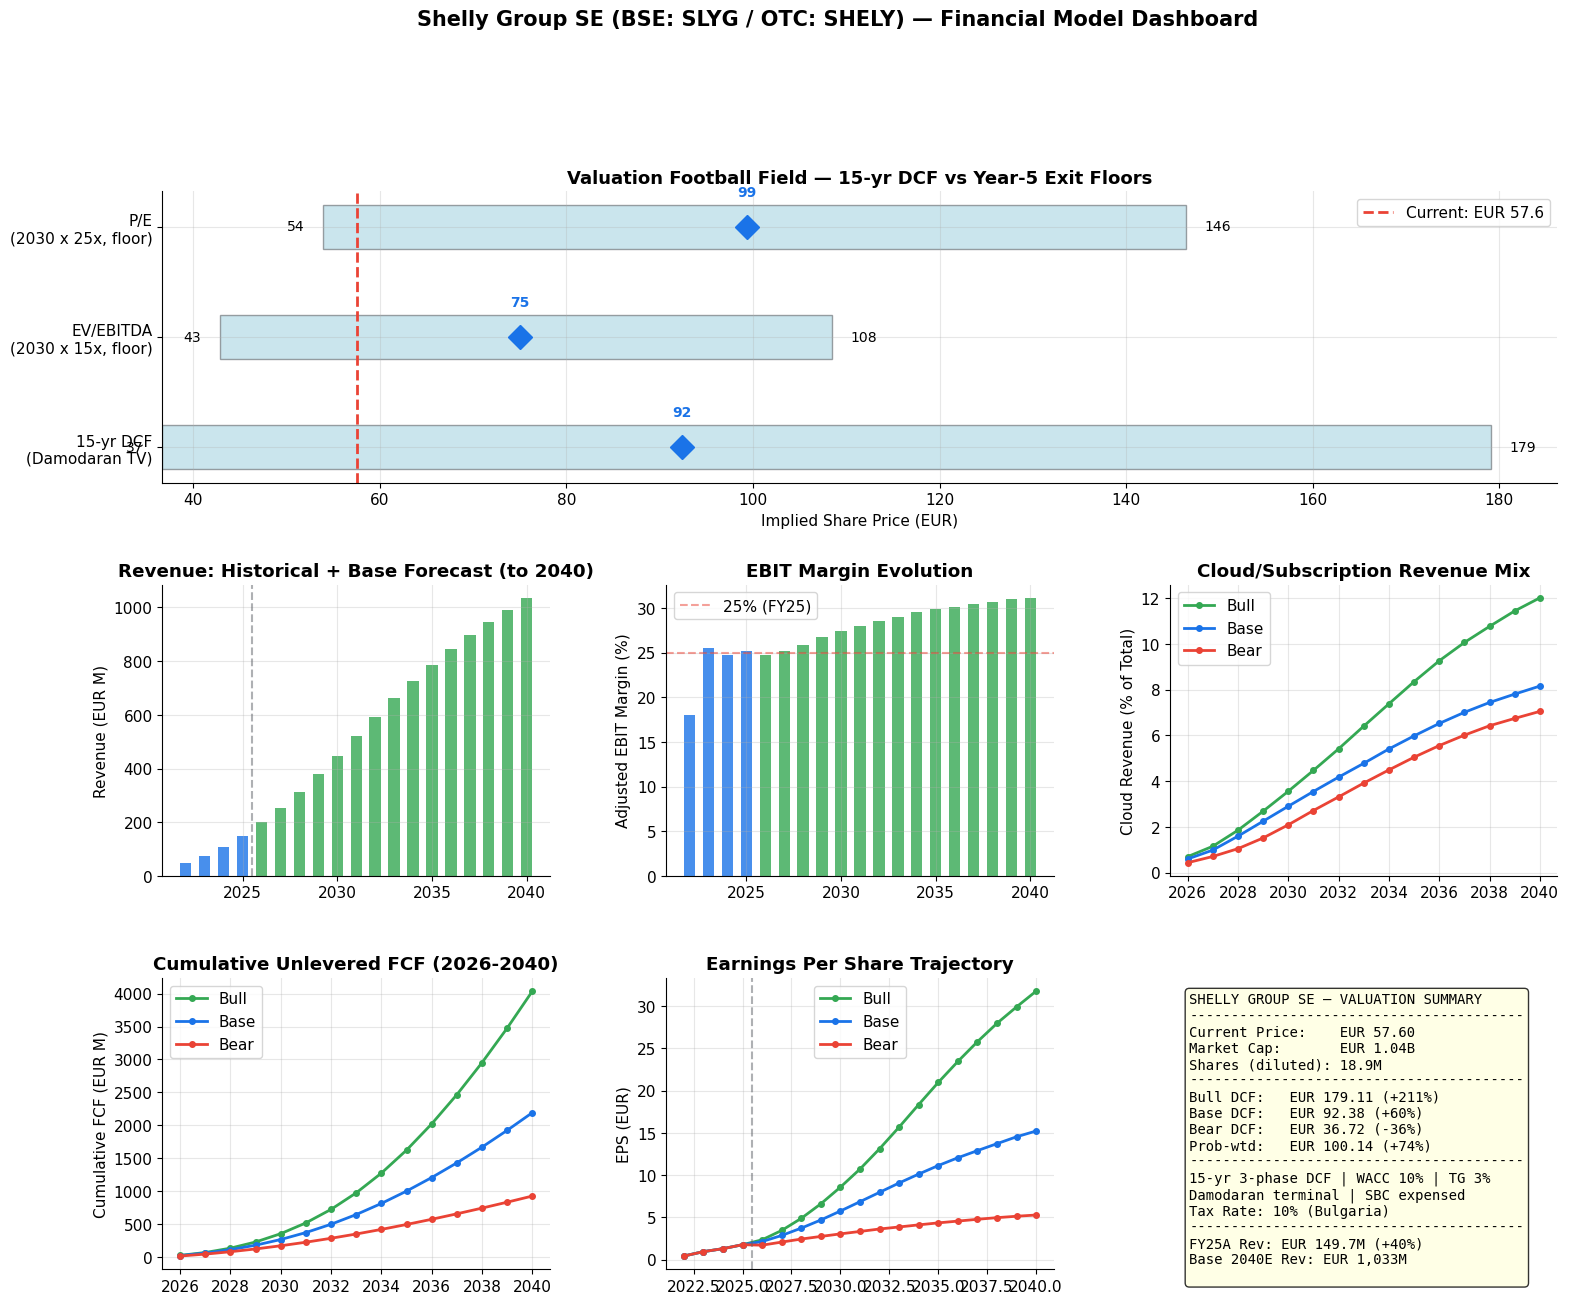


MODEL COMPLETE — 15-year three-phase DCF. All outputs generated.


In [20]:
# ── Cell 25: Key Metrics Dashboard & Final Output ───────────

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
n_hist = len(income_stmt); n_proj = len(proj_years)

# 1) Valuation Football Field — DCF (15-yr) vs year-5 exit floors
ax1 = fig.add_subplot(gs[0, :])
methods = ['15-yr DCF\n(Damodaran TV)', 'EV/EBITDA\n(2030 x 15x, floor)', 'P/E\n(2030 x 25x, floor)']
bull_vals, base_vals, bear_vals = [], [], []
bull_vals.append(dcf_results['Bull']['Implied_Price'])
base_vals.append(dcf_results['Base']['Implied_Price'])
bear_vals.append(dcf_results['Bear']['Implied_Price'])
for name, vlist in [('Bull', bull_vals), ('Base', base_vals), ('Bear', bear_vals)]:
    vlist.append(year5_exit_price(name, 'EBITDA_K', 15))
for name, vlist in [('Bull', bull_vals), ('Base', base_vals), ('Bear', bear_vals)]:
    proj = projections[name]
    pv_interim = sum(proj.loc[2025 + k, 'FCF_K'] / (1.10 ** k) for k in range(1, 6))
    px = (proj.loc[2030, 'Net_Income_K'] * 25 / discount_5yr + pv_interim) / (18.9 * 1000)
    vlist.append(px)

y_pos = np.arange(len(methods))
for i in range(len(methods)):
    lo, hi, mid = bear_vals[i], bull_vals[i], base_vals[i]
    ax1.barh(i, hi - lo, left=lo, height=0.4, color=COLORS['light'], alpha=0.6, edgecolor=COLORS['neutral'])
    ax1.plot(mid, i, 'D', color=COLORS['primary'], markersize=12, zorder=5)
    ax1.text(lo - 2, i, f'{lo:.0f}', ha='right', va='center', fontsize=10)
    ax1.text(hi + 2, i, f'{hi:.0f}', ha='left', va='center', fontsize=10)
    ax1.text(mid, i + 0.25, f'{mid:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=COLORS['primary'])
ax1.axvline(x=current_price, color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Current: EUR {current_price}')
ax1.set_yticks(y_pos); ax1.set_yticklabels(methods)
ax1.set_xlabel('Implied Share Price (EUR)')
ax1.set_title('Valuation Football Field — 15-yr DCF vs Year-5 Exit Floors', fontweight='bold', fontsize=13)
ax1.legend(fontsize=11)

# 2) Revenue: historical + Base forecast
ax2 = fig.add_subplot(gs[1, 0])
all_rev = pd.concat([income_stmt['Revenue'] / 1000, projections['Base']['Revenue_K'] / 1000])
ax2.bar(all_rev.index, all_rev.values, color=[COLORS['primary']] * n_hist + [COLORS['secondary']] * n_proj, alpha=0.8, width=0.6)
ax2.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax2.set_ylabel('Revenue (EUR M)'); ax2.set_title('Revenue: Historical + Base Forecast (to 2040)', fontweight='bold')

# 3) EBIT margin evolution
ax3 = fig.add_subplot(gs[1, 1])
all_em = pd.concat([income_stmt['EBIT_Margin_Adj'], projections['Base']['EBIT_Margin_Adj_Pct']])
ax3.bar(all_em.index, all_em.values, color=[COLORS['primary']] * n_hist + [COLORS['secondary']] * n_proj, alpha=0.8, width=0.6)
ax3.axhline(y=25, color=COLORS['accent'], linestyle='--', alpha=0.5, label='25% (FY25)')
ax3.set_ylabel('Adjusted EBIT Margin (%)'); ax3.set_title('EBIT Margin Evolution', fontweight='bold'); ax3.legend()

# 4) Cloud revenue as % of total
ax4 = fig.add_subplot(gs[1, 2])
for name in ['Bull', 'Base', 'Bear']:
    ax4.plot(proj_years, projections[name]['Cloud_Pct'], 'o-', color=scenario_colors[name], linewidth=2, markersize=4, label=name)
ax4.set_ylabel('Cloud Revenue (% of Total)'); ax4.set_title('Cloud/Subscription Revenue Mix', fontweight='bold'); ax4.legend()

# 5) Cumulative FCF
ax5 = fig.add_subplot(gs[2, 0])
for name in ['Bull', 'Base', 'Bear']:
    ax5.plot(proj_years, projections[name]['FCF_K'].cumsum() / 1000, 'o-', color=scenario_colors[name], linewidth=2, markersize=4, label=name)
ax5.set_ylabel('Cumulative FCF (EUR M)'); ax5.set_title('Cumulative Unlevered FCF (2026-2040)', fontweight='bold'); ax5.legend()

# 6) EPS trajectory
ax6 = fig.add_subplot(gs[2, 1])
hist_eps = income_stmt['EPS_Adjusted']
for name in ['Bull', 'Base', 'Bear']:
    combined = pd.concat([hist_eps, projections[name]['Net_Income_K'] / 18_900])
    ax6.plot(combined.index, combined.values, 'o-', color=scenario_colors[name], linewidth=2, markersize=4, label=name)
ax6.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax6.set_ylabel('EPS (EUR)'); ax6.set_title('Earnings Per Share Trajectory', fontweight='bold'); ax6.legend()

# 7) Summary text box
ax7 = fig.add_subplot(gs[2, 2]); ax7.axis('off')
pw = 0.25*dcf_results['Bull']['Implied_Price'] + 0.50*dcf_results['Base']['Implied_Price'] + 0.25*dcf_results['Bear']['Implied_Price']
summary_text = (
    f"SHELLY GROUP SE — VALUATION SUMMARY\n"
    f"{'-' * 40}\n"
    f"Current Price:    EUR {current_price:.2f}\n"
    f"Market Cap:       EUR 1.04B\n"
    f"Shares (diluted): 18.9M\n"
    f"{'-' * 40}\n"
    f"Bull DCF:   EUR {dcf_results['Bull']['Implied_Price']:.2f} ({(dcf_results['Bull']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"Base DCF:   EUR {dcf_results['Base']['Implied_Price']:.2f} ({(dcf_results['Base']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"Bear DCF:   EUR {dcf_results['Bear']['Implied_Price']:.2f} ({(dcf_results['Bear']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"Prob-wtd:   EUR {pw:.2f} ({(pw/current_price-1)*100:+.0f}%)\n"
    f"{'-' * 40}\n"
    f"15-yr 3-phase DCF | WACC 10% | TG 3%\n"
    f"Damodaran terminal | SBC expensed\n"
    f"Tax Rate: 10% (Bulgaria)\n"
    f"{'-' * 40}\n"
    f"FY25A Rev: EUR 149.7M (+40%)\n"
    f"Base 2040E Rev: EUR {projections['Base'].loc[2040,'Revenue_K']/1000:,.0f}M\n"
)
ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Shelly Group SE (BSE: SLYG / OTC: SHELY) — Financial Model Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 60)
print('MODEL COMPLETE — 15-year three-phase DCF. All outputs generated.')
print('=' * 60)